### This is an implementation of the XOR classifier using alternating projections

In [24]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import jax.numpy as jnp
import jax.random as random
import tools.optimize as optimize
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
rand_key = random.key(123)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
@jax.jit
def reluActivationVectorized(x, W, z):
    """
    Vectorized ReLU activation projection.
    x is the pre-activation input, W is the identity matrix, z is the target post-activation.
    """
    
    H = W @ x

    # Solution 1: project onto inactive branch (x <= 0, output = 0)
    x_1 = jnp.clip(H, a_max=0)
    dist_1 = (H - x_1)**2 + z**2

    # Solution 2: project onto active branch (x > 0, output = x)
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    dist_2 = (H - x_2)**2 + (z - x_2)**2

    # Select solution minimizing distance
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, 0.0, x_2)

    return new_H, W, new_z

In [26]:
### setup problem
xor_X = jnp.array([[0, 1, 0, 1],
                  [0, 0, 1, 1]])
xor_y = jnp.array([0, 1, 1, 1])

optimizer = optimize.AlternatingProjection
delta = 1.0

# Experiment Parameters
num_trials = 15
num_iterations = 5000

In [19]:
### Run Alternating Projections Experiment
results = []
key = rand_key

for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    # W0 is 10x3 to account for 2 inputs + 1 bias
    W0 = random.normal(k1, (10, 3))
    W0=  W0.at[:, 2].set(0)

    # W1 is 1x11 to account for 10 hidden units + 1 bias
    W1 = random.normal(k2, (1, 11))
    W1=  W1.at[10].set(0)


    # Initialize Optimizers (using vectorized versions where applicable)
    optInput      = optimizer([], [projections.matmul_proj])
    optActivation = optimizer([], [reluActivationVectorized])
    optHidden     = optimizer([], [projections.matmul_proj])
    optOutput     = optimizer([lambda x, w, y: projections.classifierOutputVector(x, w, y, delta=delta)], [])
    
    # Training Loop
    for i in tqdm(range(num_iterations), desc=f"Trial {trial+1}"):
        
        # ------------------------------------------------------------------
        # VECTORIZED FORWARD PASS 
        # ------------------------------------------------------------------
        
        x_in        = xor_X
        # Append a row of 1s for the bias
        x_in_aug    = jnp.vstack((x_in, jnp.ones((1, x_in.shape[1]))))
        
        x_hidden    = W0 @ x_in_aug
        h_hidden    = jnp.maximum(x_hidden, 0.0)   # ReLU activation
        
        # Append a row of 1s for the bias
        h_hidden_aug = jnp.vstack((h_hidden, jnp.ones((1, h_hidden.shape[1]))))
        x_out       = W1 @ h_hidden_aug

        # Calculate error
        y_target = jnp.atleast_2d(xor_y)
        err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
        err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
        batchError = err1 + err0

        # ------------------------------------------------------------------
        # VECTORIZED BACKWARD PASS
        # ------------------------------------------------------------------
        
        # Output layer constraint projection
        x_out, _, _ = optOutput.step_layer(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden_aug, W1, x_out = optHidden.step_layer(h_hidden_aug, W1, x_out)
        h_hidden = h_hidden_aug[:-1, :]

        # Activation layer step projection
        x_hidden, _, h_hidden = optActivation.step_layer(x_hidden, jnp.eye(10), h_hidden)

        # Input layer matmul projection
        x_in_aug, W0, x_hidden = optInput.step_layer(x_in_aug, W0, x_hidden)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i,
            "Error":     float(current_error),
        })

print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

NameError: name 'reluActivationVectorized' is not defined

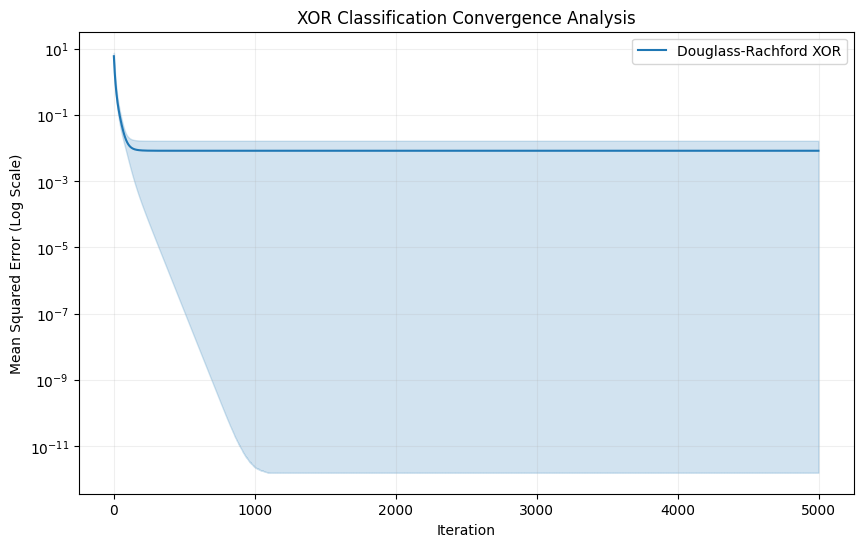

In [17]:
### Visualize Results
import numpy as np
df_results = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x="Iteration", y="Error", label='Douglass-Rachford XOR', err_style="band", errorbar=("se", 1),
)

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()